In [ ]:
# ============================================================
# ScoreSync
# GTU Student Performance Prediction
# Cell 1 - Setup
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

import joblib
import os

# Reproducibility
np.random.seed(42)

# Create folders for the project
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("ScoreSync ML environment ready.")
print("Libraries loaded successfully.")
print("Folders created: models/ and outputs/")

ScoreSync ML environment ready.
Libraries loaded successfully.
Folders created: models/ and outputs/


In [ ]:
# ============================================================
# ScoreSync
# Cell 2 - Create GTU-Style Student Dataset
# ============================================================

import numpy as np
import pandas as pd

np.random.seed(42)

N = 1200

branches = [
    "Civil Engineering",
    "Computer Engineering",
    "Information Technology",
    "Mechanical Engineering",
    "Electrical Engineering",
    "Electronics Engineering"
]

genders = ["Male", "Female"]

data = pd.DataFrame({

    "branch": np.random.choice(
        branches,
        N,
        p=[0.20, 0.22, 0.16, 0.15, 0.15, 0.12]
    ),

    "semester": np.random.choice(
        [4, 5, 6, 7],
        N
    ),

    "age": np.random.randint(
        19,
        24,
        N
    ),

    "gender": np.random.choice(
        genders,
        N
    ),

    # Academic features
    "previous_cgpa": np.round(
        np.random.uniform(5.0, 9.5, N),
        2
    ),

    "attendance": np.round(
        np.random.uniform(55, 100, N),
        1
    ),

    "internal_marks": np.round(
        np.random.uniform(10, 30, N),
        1
    ),

    "assignment_score": np.round(
        np.random.uniform(40, 100, N),
        1
    ),

    "practical_score": np.round(
        np.random.uniform(40, 100, N),
        1
    ),

    # Study habits
    "study_hours": np.round(
        np.random.uniform(0.5, 7, N),
        1
    ),

    "classes_attended": np.round(
        np.random.uniform(50, 100, N),
        1
    ),

    "assignment_completion": np.round(
        np.random.uniform(40, 100, N),
        1
    ),

    # Academic risk
    "backlogs": np.random.randint(
        0,
        5,
        N
    )
})


# ============================================================
# CREATE A REALISTIC FINAL SCORE
# ============================================================

# Start with a weighted academic formula.
# Small random noise makes the dataset less perfectly predictable.

score = (

    data["previous_cgpa"] * 5.0 +

    data["attendance"] * 0.08 +

    data["internal_marks"] * 0.65 +

    data["assignment_score"] * 0.08 +

    data["practical_score"] * 0.07 +

    data["study_hours"] * 1.1 +

    data["classes_attended"] * 0.04 +

    data["assignment_completion"] * 0.04 -

    data["backlogs"] * 2.5 +

    np.random.normal(0, 3.5, N)
)


# Convert to percentage-like score
score = np.clip(score, 35, 95)

data["final_percentage"] = np.round(
    score,
    1
)


# ============================================================
# PASS / AT RISK TARGET
# ============================================================

data["pass_fail"] = np.where(
    data["final_percentage"] >= 50,
    "Pass",
    "At Risk"
)


# ============================================================
# SAVE DATASET
# ============================================================

data.to_csv(
    "gtu_student_performance.csv",
    index=False
)


# ============================================================
# DISPLAY
# ============================================================

print("ScoreSync dataset created successfully.")
print()
print("Number of students:", len(data))
print("Number of features:", len(data.columns))
print()

display(data.head(10))

print()
print("Dataset shape:", data.shape)
print()
print("Pass / At Risk distribution:")
print(data["pass_fail"].value_counts())

ScoreSync dataset created successfully.

Number of students: 1200
Number of features: 15



,branch,semester,age,gender,previous_cgpa,attendance,internal_marks,assignment_score,practical_score,study_hours,classes_attended,assignment_completion,backlogs,final_percentage,pass_fail
0,Computer Engineering,4,23,Male,5.97,97.0,14.9,85.2,72.1,1.2,71.8,72.0,3,56.6,Pass
1,Electronics Engineering,7,22,Male,6.91,55.9,26.0,68.4,89.4,2.8,70.1,91.5,4,65.7,Pass
2,Electrical Engineering,6,23,Female,9.09,61.9,12.1,66.8,46.2,6.2,78.8,84.2,3,68.1,Pass
3,Mechanical Engineering,4,20,Male,7.28,94.9,25.6,40.4,96.6,1.8,79.2,52.9,3,71.2,Pass
4,Civil Engineering,6,22,Male,5.85,75.6,28.2,89.2,87.7,1.0,87.5,64.0,0,75.2,Pass
5,Civil Engineering,4,21,Male,5.35,80.4,17.7,61.6,50.9,5.6,75.5,70.5,2,64.3,Pass
6,Civil Engineering,5,22,Male,8.13,84.8,22.6,72.4,82.7,5.9,55.2,88.6,1,86.2,Pass
7,Electrical Engineering,6,21,Male,6.72,85.6,18.6,80.6,63.1,1.6,92.9,90.3,0,71.5,Pass
8,Mechanical Engineering,6,21,Female,8.70,96.9,18.8,82.2,64.1,6.1,65.5,94.6,1,81.0,Pass
9,Mechanical Engineering,7,22,Female,7.97,99.9,16.2,97.4,87.0,5.0,98.6,70.6,3,78.5,Pass



Dataset shape: (1200, 15)

Pass / At Risk distribution:
pass_fail
Pass       1184
At Risk      16
Name: count, dtype: int64


Dataset loaded successfully.

Dataset Shape:
(1200, 15)

Columns:
['branch', 'semester', 'age', 'gender', 'previous_cgpa', 'attendance', 'internal_marks', 'assignment_score', 'practical_score', 'study_hours', 'classes_attended', 'assignment_completion', 'backlogs', 'final_percentage', 'pass_fail']

Missing Values:
branch                   0
semester                 0
age                      0
gender                   0
previous_cgpa            0
attendance               0
internal_marks           0
assignment_score         0
practical_score          0
study_hours              0
classes_attended         0
assignment_completion    0
backlogs                 0
final_percentage         0
pass_fail                0
dtype: int64

Dataset Statistics:


,semester,age,previous_cgpa,attendance,internal_marks,assignment_score,practical_score,study_hours,classes_attended,assignment_completion,backlogs,final_percentage
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,5.474167,21.035833,7.202883,77.476167,19.898417,69.22050,69.560583,3.710583,75.368000,69.916917,1.941667,70.588000
std,1.129334,1.418765,1.287985,13.024303,5.822413,17.08311,16.814315,1.862696,14.368402,17.525716,1.402939,9.581542
min,4.000000,19.000000,5.000000,55.000000,10.000000,40.00000,40.000000,0.500000,50.100000,40.000000,0.000000,39.800000
25%,4.000000,20.000000,6.070000,66.200000,14.800000,54.65000,55.500000,2.100000,63.275000,54.400000,1.000000,63.500000
50%,5.000000,21.000000,7.200000,76.850000,19.700000,69.15000,69.450000,3.700000,75.300000,69.500000,2.000000,70.600000
75%,7.000000,22.000000,8.290000,88.800000,25.200000,83.20000,83.500000,5.300000,87.900000,85.500000,3.000000,77.700000
max,7.000000,23.000000,9.500000,99.900000,30.000000,99.90000,99.900000,7.000000,100.000000,99.900000,4.000000,95.000000


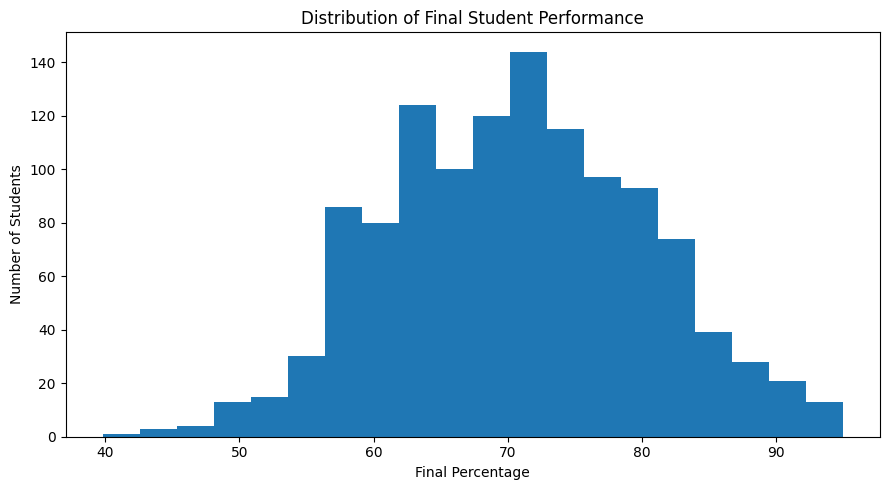

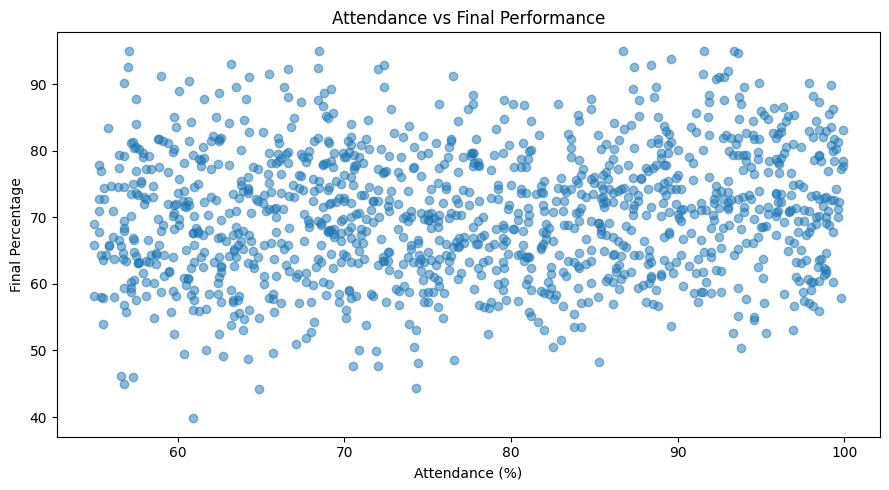

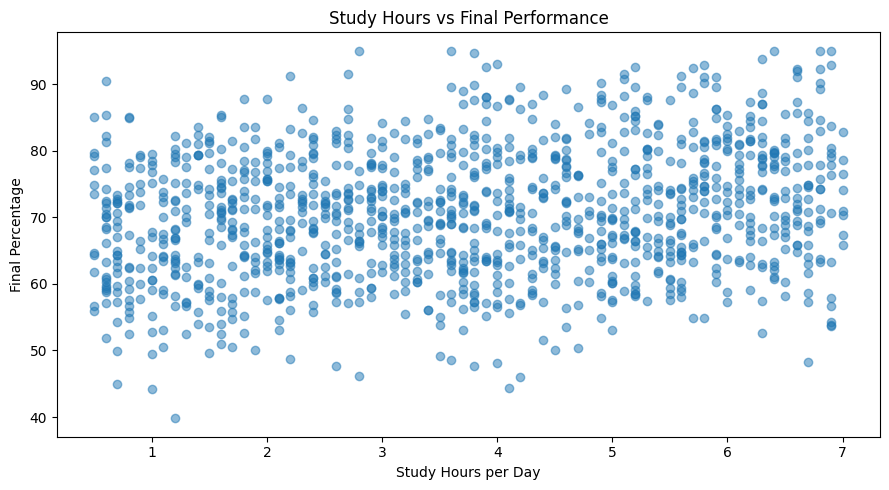

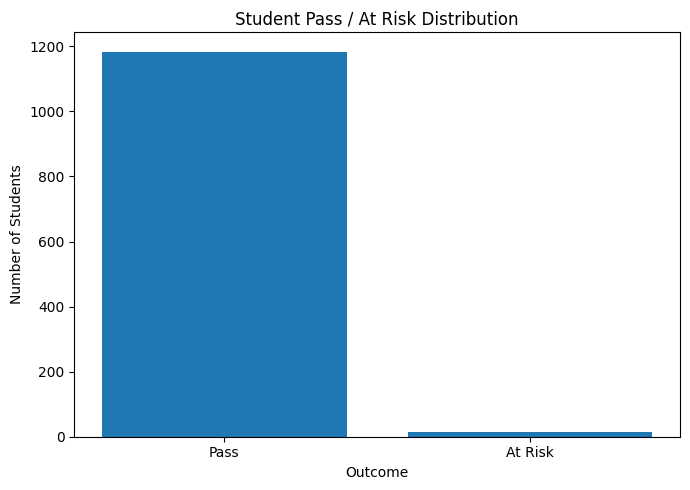


Correlation with Final Percentage:


,final_percentage
final_percentage,1.000000
previous_cgpa,0.653899
internal_marks,0.425577
study_hours,0.215298
assignment_score,0.148381
attendance,0.123348
practical_score,0.112597
assignment_completion,0.102498
classes_attended,0.053968
age,0.022616


In [ ]:



# ============================================================
# ScoreSync
# Cell 3 - Data Exploration & Visualization
# ============================================================

# Load the dataset
data = pd.read_csv("gtu_student_performance.csv")

print("Dataset loaded successfully.")
print()

# ------------------------------------------------------------
# BASIC INFORMATION
# ------------------------------------------------------------

print("Dataset Shape:")
print(data.shape)

print("\nColumns:")
print(list(data.columns))

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDataset Statistics:")
display(data.describe())


# ============================================================
# GRAPH 1 - FINAL PERCENTAGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    data["final_percentage"],
    bins=20
)

plt.xlabel("Final Percentage")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Student Performance")

plt.tight_layout()

plt.savefig(
    "outputs/final_percentage_distribution.png",
    dpi=150
)

plt.show()


# ============================================================
# GRAPH 2 - ATTENDANCE VS FINAL PERFORMANCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    data["attendance"],
    data["final_percentage"],
    alpha=0.5
)

plt.xlabel("Attendance (%)")
plt.ylabel("Final Percentage")
plt.title("Attendance vs Final Performance")

plt.tight_layout()

plt.savefig(
    "outputs/attendance_vs_performance.png",
    dpi=150
)

plt.show()


# ============================================================
# GRAPH 3 - STUDY HOURS VS PERFORMANCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    data["study_hours"],
    data["final_percentage"],
    alpha=0.5
)

plt.xlabel("Study Hours per Day")
plt.ylabel("Final Percentage")
plt.title("Study Hours vs Final Performance")

plt.tight_layout()

plt.savefig(
    "outputs/study_hours_vs_performance.png",
    dpi=150
)

plt.show()


# ============================================================
# GRAPH 4 - PASS VS AT RISK
# ============================================================

counts = data["pass_fail"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    counts.index,
    counts.values
)

plt.xlabel("Outcome")
plt.ylabel("Number of Students")
plt.title("Student Pass / At Risk Distribution")

plt.tight_layout()

plt.savefig(
    "outputs/pass_fail_distribution.png",
    dpi=150
)

plt.show()


# ============================================================
# CORRELATION ANALYSIS
# ============================================================

numeric_columns = data.select_dtypes(
    include=np.number
)

correlation = numeric_columns.corr()

print("\nCorrelation with Final Percentage:")

display(
    correlation["final_percentage"]
    .sort_values(ascending=False)
)

In [ ]:
# ============================================================
# ScoreSync
# Cell 4 - Data Preparation
# ============================================================

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load dataset
data = pd.read_csv("gtu_student_performance.csv")

# ------------------------------------------------------------
# FEATURES AND TARGETS
# ------------------------------------------------------------

# Features used by the model
X = data.drop(
    columns=[
        "final_percentage",
        "pass_fail"
    ]
)

# Regression target
y_regression = data["final_percentage"]

# Classification target
y_classification = data["pass_fail"]


# ------------------------------------------------------------
# IDENTIFY COLUMN TYPES
# ------------------------------------------------------------

categorical_features = [
    "branch",
    "gender"
]

numerical_features = [
    "semester",
    "age",
    "previous_cgpa",
    "attendance",
    "internal_marks",
    "assignment_score",
    "practical_score",
    "study_hours",
    "classes_attended",
    "assignment_completion",
    "backlogs"
]


# ------------------------------------------------------------
# ENCODE CATEGORICAL DATA
# ------------------------------------------------------------

preprocessor = ColumnTransformer(

    transformers=[

        (
            "categorical",

            OneHotEncoder(
                handle_unknown="ignore"
            ),

            categorical_features
        )

    ],

    remainder="passthrough"
)


# ------------------------------------------------------------
# TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_reg_train, y_reg_test = train_test_split(

    X,
    y_regression,

    test_size=0.20,

    random_state=42
)


# Classification split
_, _, y_clf_train, y_clf_test = train_test_split(

    X,
    y_classification,

    test_size=0.20,

    random_state=42
)


# ------------------------------------------------------------
# TRANSFORM DATA
# ------------------------------------------------------------

X_train_encoded = preprocessor.fit_transform(
    X_train
)

X_test_encoded = preprocessor.transform(
    X_test
)


print("Data preparation complete.")
print()

print("Training samples:",
      X_train.shape[0])

print("Testing samples:",
      X_test.shape[0])

print()

print("Original features:",
      X.shape[1])

print("Encoded features:",
      X_train_encoded.shape[1])

print()

print("Training data ready for machine learning.")

Data preparation complete.

Training samples: 960
Testing samples: 240

Original features: 13
Encoded features: 19

Training data ready for machine learning.


In [ ]:
# ============================================================
# ScoreSync
# Cell 5 - Train Machine Learning Models
# ============================================================

from sklearn.pipeline import Pipeline

# ============================================================
# REGRESSION MODELS
# ============================================================

regression_models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=10
    )
}


# ============================================================
# CLASSIFICATION MODELS
# ============================================================

classification_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        max_depth=10
    )
}


# ============================================================
# TRAIN REGRESSION MODELS
# ============================================================

regression_results = {}

trained_regressors = {}

print("TRAINING REGRESSION MODELS")
print("=" * 45)

for name, model in regression_models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(
        X_train,
        y_reg_train
    )

    predictions = pipeline.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_reg_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_reg_test,
            predictions
        )
    )

    r2 = r2_score(
        y_reg_test,
        predictions
    )

    regression_results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    trained_regressors[name] = pipeline

    print(f"\n{name}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.3f}")


# ============================================================
# TRAIN CLASSIFICATION MODELS
# ============================================================

classification_results = {}

trained_classifiers = {}

print("\n\nTRAINING CLASSIFICATION MODELS")
print("=" * 45)

for name, model in classification_models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(
        X_train,
        y_clf_train
    )

    predictions = pipeline.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_clf_test,
        predictions
    )

    classification_results[name] = {
        "Accuracy": accuracy
    }

    trained_classifiers[name] = pipeline

    print(f"\n{name}")
    print(
        f"Accuracy : {accuracy:.3f}"
    )


# ============================================================
# FIND BEST MODELS
# ============================================================

best_regressor_name = max(
    regression_results,
    key=lambda x: regression_results[x]["R2"]
)

best_classifier_name = max(
    classification_results,
    key=lambda x: classification_results[x]["Accuracy"]
)


best_regressor = trained_regressors[
    best_regressor_name
]

best_classifier = trained_classifiers[
    best_classifier_name
]


# ============================================================
# RESULTS
# ============================================================

print("\n")
print("=" * 55)

print(
    f"BEST REGRESSION MODEL : "
    f"{best_regressor_name}"
)

print(
    f"BEST CLASSIFICATION MODEL : "
    f"{best_classifier_name}"
)

print("=" * 55)

TRAINING REGRESSION MODELS

Linear Regression
MAE  : 2.87
RMSE : 3.62
R²   : 0.853

Random Forest
MAE  : 3.35
RMSE : 4.14
R²   : 0.808


TRAINING CLASSIFICATION MODELS

Logistic Regression
Accuracy : 0.988

Random Forest
Accuracy : 0.979


BEST REGRESSION MODEL : Linear Regression
BEST CLASSIFICATION MODEL : Logistic Regression


In [ ]:
# ============================================================
# ScoreSync
# Cell 6 - Save Best Models
# ============================================================

# Save the winning regression model
joblib.dump(
    best_regressor,
    "models/scoresync_regression.pkl"
)

# Save the winning classification model
joblib.dump(
    best_classifier,
    "models/scoresync_classification.pkl"
)

# Save the preprocessing information
joblib.dump(
    preprocessor,
    "models/scoresync_preprocessor.pkl"
)

print("ScoreSync models saved successfully.")
print()
print("Regression model:")
print("  models/scoresync_regression.pkl")
print()
print("Classification model:")
print("  models/scoresync_classification.pkl")
print()
print("Preprocessor:")
print("  models/scoresync_preprocessor.pkl")

ScoreSync models saved successfully.

Regression model:
  models/scoresync_regression.pkl

Classification model:
  models/scoresync_classification.pkl

Preprocessor:
  models/scoresync_preprocessor.pkl


In [ ]:
# ============================================================
# ScoreSync
# Cell 7 - Test Prediction
# ============================================================

# Example GTU engineering student
student = pd.DataFrame([{

    "branch": "Civil Engineering",
    "semester": 6,
    "age": 21,
    "gender": "Male",

    "previous_cgpa": 7.4,
    "attendance": 82,
    "internal_marks": 24,
    "assignment_score": 85,
    "practical_score": 78,

    "study_hours": 3.0,
    "classes_attended": 82,
    "assignment_completion": 90,

    "backlogs": 0
}])


# ------------------------------------------------------------
# LOAD SAVED MODELS
# ------------------------------------------------------------

regressor = joblib.load(
    "models/scoresync_regression.pkl"
)

classifier = joblib.load(
    "models/scoresync_classification.pkl"
)


# ------------------------------------------------------------
# PREDICT
# ------------------------------------------------------------

predicted_percentage = regressor.predict(
    student
)[0]

predicted_outcome = classifier.predict(
    student
)[0]


# Keep percentage between 0 and 100
predicted_percentage = np.clip(
    predicted_percentage,
    0,
    100
)


# ------------------------------------------------------------
# DISPLAY RESULT
# ------------------------------------------------------------

print("=" * 50)
print("SCORESYNC TEST PREDICTION")
print("=" * 50)

print()
print("Student:")
print("Branch       :", student["branch"].iloc[0])
print("Semester     :", student["semester"].iloc[0])
print("CGPA         :", student["previous_cgpa"].iloc[0])
print("Attendance   :", student["attendance"].iloc[0], "%")
print("Internal     :", student["internal_marks"].iloc[0])
print("Study Hours  :", student["study_hours"].iloc[0])
print("Backlogs     :", student["backlogs"].iloc[0])

print()
print("-" * 50)

print(
    f"Predicted Percentage : {predicted_percentage:.1f}%"
)

print(
    f"Predicted Outcome    : {predicted_outcome}"
)

print("=" * 50)

SCORESYNC TEST PREDICTION

Student:
Branch       : Civil Engineering
Semester     : 6
CGPA         : 7.4
Attendance   : 82 %
Internal     : 24
Study Hours  : 3.0
Backlogs     : 0

--------------------------------------------------
Predicted Percentage : 81.7%
Predicted Outcome    : Pass


In [ ]:
# ============================================================
# ScoreSync
# NEW GTU TARGETS
# Predict:
#   1. Current Semester SPI
#   2. Overall CGPA
#   3. Academic Status
# ============================================================

np.random.seed(42)

data = pd.read_csv("gtu_student_performance.csv")

# ------------------------------------------------------------
# CREATE CURRENT SEMESTER SPI
# ------------------------------------------------------------

spi = (
    data["previous_cgpa"] * 0.35
    + (data["attendance"] / 100) * 0.8
    + (data["internal_marks"] / 30) * 2.0
    + (data["assignment_score"] / 100) * 0.8
    + (data["practical_score"] / 100) * 0.8
    + (data["study_hours"] / 7) * 0.7
    + (data["classes_attended"] / 100) * 0.5
    + (data["assignment_completion"] / 100) * 0.5
    - data["backlogs"] * 0.35
    + np.random.normal(0, 0.25, len(data))
)

data["current_spi"] = np.clip(
    spi,
    4.0,
    10.0
).round(2)


# ------------------------------------------------------------
# CREATE OVERALL CGPA
# ------------------------------------------------------------

# Overall CGPA is influenced by previous CGPA
# and the predicted current semester SPI.

data["overall_cgpa"] = (
    (
        data["previous_cgpa"] * 5
        + data["current_spi"]
    ) / 6
    + np.random.normal(0, 0.08, len(data))
)

data["overall_cgpa"] = np.clip(
    data["overall_cgpa"],
    4.0,
    10.0
).round(2)


# ------------------------------------------------------------
# ACADEMIC STATUS
# ------------------------------------------------------------

data["academic_status"] = np.where(
    data["current_spi"] >= 6.0,
    "On Track",
    "At Risk"
)


# ------------------------------------------------------------
# REMOVE OLD TARGETS
# ------------------------------------------------------------

data = data.drop(
    columns=[
        "final_percentage",
        "pass_fail"
    ],
    errors="ignore"
)


# ------------------------------------------------------------
# SAVE NEW DATASET
# ------------------------------------------------------------

data.to_csv(
    "scoresync_gtu_dataset.csv",
    index=False
)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("ScoreSync GTU dataset updated.")
print()

display(
    data.head(10)
)

print()
print("Dataset shape:", data.shape)

print()
print("Target columns:")
print("Current SPI   :", data["current_spi"].min(),
      "to", data["current_spi"].max())

print("Overall CGPA  :", data["overall_cgpa"].min(),
      "to", data["overall_cgpa"].max())

print()
print("Academic Status:")
print(
    data["academic_status"].value_counts()
)

ScoreSync GTU dataset updated.



,branch,semester,age,gender,previous_cgpa,attendance,internal_marks,assignment_score,practical_score,study_hours,classes_attended,assignment_completion,backlogs,current_spi,overall_cgpa,academic_status
0,Computer Engineering,4,23,Male,5.97,97.0,14.9,85.2,72.1,1.2,71.8,72.0,3,5.03,5.82,At Risk
1,Electronics Engineering,7,22,Male,6.91,55.9,26.0,68.4,89.4,2.8,70.1,91.5,4,5.51,6.64,At Risk
2,Electrical Engineering,6,23,Female,9.09,61.9,12.1,66.8,46.2,6.2,78.8,84.2,3,5.93,8.57,At Risk
3,Mechanical Engineering,4,20,Male,7.28,94.9,25.6,40.4,96.6,1.8,79.2,52.9,3,6.28,7.16,On Track
4,Civil Engineering,6,22,Male,5.85,75.6,28.2,89.2,87.7,1.0,87.5,64.0,0,6.75,6.00,On Track
5,Civil Engineering,4,21,Male,5.35,80.4,17.7,61.6,50.9,5.6,75.5,70.5,2,5.13,5.32,At Risk
6,Civil Engineering,5,22,Male,8.13,84.8,22.6,72.4,82.7,5.9,55.2,88.6,1,7.63,7.99,On Track
7,Electrical Engineering,6,21,Male,6.72,85.6,18.6,80.6,63.1,1.6,92.9,90.3,0,6.69,6.66,On Track
8,Mechanical Engineering,6,21,Female,8.70,96.9,18.8,82.2,64.1,6.1,65.5,94.6,1,7.19,8.34,On Track
9,Mechanical Engineering,7,22,Female,7.97,99.9,16.2,97.4,87.0,5.0,98.6,70.6,3,6.58,7.88,On Track



Dataset shape: (1200, 16)

Target columns:
Current SPI   : 4.0 to 9.08
Overall CGPA  : 4.83 to 9.43

Academic Status:
academic_status
At Risk     600
On Track    600
Name: count, dtype: int64


In [42]:
# ============================================================
# SCORE SYNC
# FINAL UI
# ============================================================

import gradio as gr


# ============================================================
# CSS
# ============================================================

CSS = """

/* ============================================================
   PAGE
   ============================================================ */

body {
    background: #10131c !important;
}

.gradio-container {
    max-width: 1150px !important;
    margin: auto !important;
    padding: 0 !important;
    background: #10131c !important;
}


/* ============================================================
   LOGO
   ============================================================ */

.logo {
    text-align: center;

    font-size: 52px;

    font-weight: 700;

    letter-spacing: -2px;

    color: white;

    margin-top: 35px;

    margin-bottom: 6px;
}

.logo span {
    color: #7567f8;
}

.tagline {
    text-align: center;

    color: #858b9c;

    font-size: 16px;

    margin-bottom: 38px;
}


/* ============================================================
   AUTH AREA
   ============================================================ */

.auth-box {
    width: 600px !important;

    max-width: 90vw !important;

    margin: 0 auto !important;

    padding: 35px !important;

    background: #191c25 !important;

    border: 1px solid #303544 !important;

    border-radius: 9px !important;
}


/* ============================================================
   AUTH TITLES
   ============================================================ */

.title {
    text-align: center;

    color: white;

    font-size: 30px;

    font-weight: 600;

    margin-bottom: 7px;
}

.subtitle {
    text-align: center;

    color: #858b9c;

    font-size: 15px;

    margin-bottom: 28px;
}


/* ============================================================
   AUTH INPUTS
   ============================================================ */

.auth-box input {
    background: #11141b !important;

    color: white !important;

    border: 1px solid #363b4b !important;

    border-radius: 6px !important;

    min-height: 48px !important;

    font-size: 15px !important;
}

.auth-box input:focus {
    border-color: #7567f8 !important;
}


/* ============================================================
   BUTTONS
   ============================================================ */

.primary button {
    background: #7567f8 !important;

    color: white !important;

    border: none !important;

    border-radius: 6px !important;

    min-height: 50px !important;

    font-size: 16px !important;

    font-weight: 600 !important;
}

.primary button:hover {
    background: #877bf9 !important;
}


.link button {
    background: transparent !important;

    color: #8d82fa !important;

    border: none !important;

    box-shadow: none !important;

    font-size: 14px !important;
}


/* ============================================================
   DASHBOARD
   ============================================================ */

#dashboard {
    width: 100% !important;

    max-width: 1050px !important;

    margin: auto !important;

    padding: 25px 20px 50px 20px !important;
}


.dashboard-title {
    color: white;

    font-size: 32px;

    font-weight: 600;

    margin-top: 15px;
}

.dashboard-subtitle {
    color: #858b9c;

    font-size: 15px;

    margin-bottom: 25px;
}


/* ============================================================
   RESULT CARDS
   ============================================================ */

.stat input {
    font-size: 21px !important;

    font-weight: 600 !important;
}


/* ============================================================
   SECTION HEADINGS
   ============================================================ */

.section-title {
    color: white;

    font-size: 21px;

    font-weight: 600;

    margin-top: 28px;

    margin-bottom: 5px;
}

.section-subtitle {
    color: #858b9c;

    font-size: 14px;

    margin-bottom: 18px;
}


/* ============================================================
   PREDICT
   ============================================================ */

.predict button {
    background: #7567f8 !important;

    color: white !important;

    border: none !important;

    border-radius: 6px !important;

    min-height: 50px !important;

    font-size: 16px !important;

    font-weight: 600 !important;

    margin-top: 18px !important;
}

.predict button:hover {
    background: #877bf9 !important;
}


/* ============================================================
   MOBILE
   ============================================================ */

@media(max-width:700px) {

    .auth-box {
        width: auto !important;

        max-width: 88vw !important;

        padding: 25px !important;
    }

    .logo {
        font-size: 42px;
    }

    .dashboard-title {
        font-size: 27px;
    }
}

"""


# ============================================================
# APPLICATION
# ============================================================

with gr.Blocks(
    title="ScoreSync"
) as app:

    # ========================================================
    # STATE
    # ========================================================

    current_user = gr.State(None)


    # ========================================================
    # BRAND
    # ========================================================

    gr.HTML("""
    <div class="logo">
        Score<span>Sync</span>
    </div>

    <div class="tagline">
        Student Performance Intelligence
    </div>
    """)


    # ========================================================
    # SIGN IN
    # ========================================================

    with gr.Column(
        visible=True
    ) as signin_page:

        with gr.Column(
            elem_classes="auth-box"
        ):

            gr.HTML("""
            <div class="title">
                Welcome back
            </div>

            <div class="subtitle">
                Sign in to continue
            </div>
            """)


            login_email = gr.Textbox(
                label="Email",
                placeholder="student@example.com"
            )


            login_password = gr.Textbox(
                label="Password",
                type="password",
                placeholder="Enter your password"
            )


            login_button = gr.Button(
                "Sign In",
                elem_classes="primary"
            )


            login_message = gr.Markdown()


            switch_signup = gr.Button(
                "Create an account",
                elem_classes="link"
            )


    # ========================================================
    # SIGN UP
    # ========================================================

    with gr.Column(
        visible=False
    ) as signup_page:

        with gr.Column(
            elem_classes="auth-box"
        ):

            gr.HTML("""
            <div class="title">
                Create your account
            </div>

            <div class="subtitle">
                Start tracking your academic performance
            </div>
            """)


            signup_name = gr.Textbox(
                label="Name",
                placeholder="Your name"
            )


            signup_email = gr.Textbox(
                label="Email",
                placeholder="student@example.com"
            )


            signup_password = gr.Textbox(
                label="Password",
                type="password",
                placeholder="Create a password"
            )


            signup_button = gr.Button(
                "Create Account",
                elem_classes="primary"
            )


            signup_message = gr.Markdown()


            switch_signin = gr.Button(
                "Already have an account? Sign in",
                elem_classes="link"
            )


    # ========================================================
    # DASHBOARD
    # ========================================================

    with gr.Column(
        visible=False,
        elem_id="dashboard"
    ) as dashboard:

        gr.Markdown(
            "Academic Performance",
            elem_classes="dashboard-title"
        )

        gr.Markdown(
            "Predict your current semester SPI and overall CGPA.",
            elem_classes="dashboard-subtitle"
        )


        # ====================================================
        # RESULTS
        # ====================================================

        with gr.Row():

            predicted_spi = gr.Textbox(
                label="Current Semester SPI",
                value="--",
                interactive=False,
                elem_classes="stat"
            )

            predicted_cgpa = gr.Textbox(
                label="Overall CGPA",
                value="--",
                interactive=False,
                elem_classes="stat"
            )

            predicted_status = gr.Textbox(
                label="Academic Status",
                value="--",
                interactive=False,
                elem_classes="stat"
            )


        # ====================================================
        # STUDENT INFORMATION
        # ====================================================

        gr.Markdown(
            "Student Information",
            elem_classes="section-title"
        )

        gr.Markdown(
            "Basic academic details used by ScoreSync.",
            elem_classes="section-subtitle"
        )


        with gr.Row():

            branch = gr.Dropdown(
                label="Engineering Branch",
                choices=[
                    "Civil Engineering",
                    "Computer Engineering",
                    "Information Technology",
                    "Mechanical Engineering",
                    "Electrical Engineering",
                    "Electronics Engineering"
                ],
                value="Civil Engineering"
            )


            semester = gr.Dropdown(
                label="Current Semester",
                choices=[
                    1, 2, 3, 4,
                    5, 6, 7, 8
                ],
                value=6
            )


        with gr.Row():

            age = gr.Slider(
                label="Age",
                minimum=17,
                maximum=30,
                value=21,
                step=1
            )


            gender = gr.Dropdown(
                label="Gender",
                choices=[
                    "Male",
                    "Female",
                    "Other"
                ],
                value="Male"
            )


        # ====================================================
        # ACADEMIC INFORMATION
        # ====================================================

        gr.Markdown(
            "Academic Information",
            elem_classes="section-title"
        )

        gr.Markdown(
            "Your current academic performance.",
            elem_classes="section-subtitle"
        )


        with gr.Row():

            previous_cgpa = gr.Slider(
                label="Previous CGPA",
                minimum=0,
                maximum=10,
                value=7,
                step=0.01
            )


            attendance = gr.Slider(
                label="Attendance (%)",
                minimum=0,
                maximum=100,
                value=75,
                step=1
            )


        with gr.Row():

            internal_marks = gr.Slider(
                label="Internal Marks",
                minimum=0,
                maximum=30,
                value=20,
                step=1
            )


            assignment_score = gr.Slider(
                label="Assignment Score",
                minimum=0,
                maximum=100,
                value=75,
                step=1
            )


        with gr.Row():

            practical_score = gr.Slider(
                label="Practical Score",
                minimum=0,
                maximum=100,
                value=75,
                step=1
            )


            backlogs = gr.Slider(
                label="Current Backlogs",
                minimum=0,
                maximum=10,
                value=0,
                step=1
            )


        # ====================================================
        # STUDY INFORMATION
        # ====================================================

        gr.Markdown(
            "Study & Participation",
            elem_classes="section-title"
        )

        gr.Markdown(
            "Study and participation factors considered by the model.",
            elem_classes="section-subtitle"
        )


        with gr.Row():

            study_hours = gr.Slider(
                label="Study Hours per Day",
                minimum=0,
                maximum=12,
                value=2,
                step=0.5
            )


            classes_attended = gr.Slider(
                label="Classes Attended (%)",
                minimum=0,
                maximum=100,
                value=75,
                step=1
            )


        assignment_completion = gr.Slider(
            label="Assignment Completion (%)",
            minimum=0,
            maximum=100,
            value=75,
            step=1
        )


        # ====================================================
        # PREDICT
        # ====================================================

        predict_button = gr.Button(
            "Predict My Performance",
            elem_classes="predict"
        )


        # ====================================================
        # HISTORY
        # ====================================================

        gr.Markdown(
            "Prediction History",
            elem_classes="section-title"
        )

        gr.Markdown(
            "Previous predictions made using ScoreSync.",
            elem_classes="section-subtitle"
        )


        history = gr.Dataframe(
            headers=[
                "Date",
                "SPI",
                "CGPA",
                "Status"
            ],
            interactive=False
        )


        refresh_button = gr.Button(
            "Refresh History"
        )


        logout_button = gr.Button(
            "Log Out"
        )


    # ========================================================
    # SIGN IN → SIGN UP
    # ========================================================

    switch_signup.click(
        fn=lambda: (
            gr.update(visible=False),
            gr.update(visible=True)
        ),
        inputs=[],
        outputs=[
            signin_page,
            signup_page
        ]
    )


    # ========================================================
    # SIGN UP → SIGN IN
    # ========================================================

    switch_signin.click(
        fn=lambda: (
            gr.update(visible=True),
            gr.update(visible=False)
        ),
        inputs=[],
        outputs=[
            signin_page,
            signup_page
        ]
    )


    # ========================================================
    # CREATE ACCOUNT
    # ========================================================

    signup_button.click(
        fn=signup,
        inputs=[
            signup_name,
            signup_email,
            signup_password
        ],
        outputs=[
            signup_message
        ]
    )


    # ========================================================
    # LOGIN
    # ========================================================

    login_button.click(
        fn=login,
        inputs=[
            login_email,
            login_password
        ],
        outputs=[
            current_user,
            login_message,
            signin_page,
            dashboard
        ]
    )


    # ========================================================
    # PREDICTION
    # ========================================================

    predict_button.click(
        fn=predict,
        inputs=[
            current_user,
            branch,
            semester,
            age,
            gender,
            previous_cgpa,
            attendance,
            internal_marks,
            assignment_score,
            practical_score,
            study_hours,
            classes_attended,
            assignment_completion,
            backlogs
        ],
        outputs=[
            predicted_spi,
            predicted_cgpa,
            predicted_status,
            history
        ]
    )


    # ========================================================
    # HISTORY
    # ========================================================

    refresh_button.click(
        fn=get_history,
        inputs=current_user,
        outputs=history
    )


    # ========================================================
    # LOGOUT
    # ========================================================

    def logout_user():
        return (
            None,
            gr.update(visible=True),
            gr.update(visible=False)
        )


    logout_button.click(
        fn=logout_user,
        inputs=[],
        outputs=[
            current_user,
            signin_page,
            dashboard
        ]
    )


# ============================================================
# LAUNCH
# ============================================================

print("========================================")
print("       ScoreSync is starting...")
print("========================================")

app.launch(
    share=True,
    css=CSS
)

       ScoreSync is starting...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://01ac38b16912e21626.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
